In [4]:
import torch
import dgl
import yaml

print("torch:", torch.__version__)
print("dgl:", dgl.__version__)
print("cuda:", torch.cuda.is_available())


torch: 2.1.0+cu121
dgl: 2.1.0+cu121
cuda: True


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import dgl
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

# ==========================
# 1. 图加载
# ==========================

def load_graph(node_csv, edge_csv, device="cpu"):
    nodes = pd.read_csv(node_csv)
    num_nodes = len(nodes)

    edges = pd.read_csv(edge_csv)
    src = torch.tensor(edges["src"].values, dtype=torch.int64)
    dst = torch.tensor(edges["dst"].values, dtype=torch.int64)

    g = dgl.graph((src, dst), num_nodes=num_nodes)
    g = dgl.add_edges(g, dst, src)
    g = dgl.add_self_loop(g)


    return g.to(device), edges, num_nodes


# ==========================
# 2. 构造训练样本
# ==========================

def sample_non_edges(num_nodes, edges, num_samples):
    exist = set()
    for s, d in zip(edges["src"], edges["dst"]):
        exist.add((s, d))
        exist.add((d, s))  # 无向视角
    samples = set()
    print(len(exist))
    while len(samples) < num_samples:
        s = np.random.randint(0, num_nodes)
        d = np.random.randint(0, num_nodes)
        if s != d and (s, d) not in exist:
            samples.add((s, d))
    print(len(samples))
    return samples


def build_samples(g, edges, num_nodes):
    pos = edges[edges["label"] == 1]
    neg = edges[edges["label"] == 2]

    src, dst, label = [], [], []

    for _, r in pos.iterrows():
        src.append(r.src)
        dst.append(r.dst)
        label.append(1)

    for _, r in neg.iterrows():
        src.append(r.src)
        dst.append(r.dst)
        label.append(2)

    # 采样无边
    non_edges = sample_non_edges(num_nodes, edges, len(pos))
    for s, d in non_edges:
        src.append(s)
        dst.append(d)
        label.append(0)

    return torch.tensor(src), torch.tensor(dst), torch.tensor(label)


# ==========================
# Dataset
# ==========================

class EdgeDataset(Dataset):
    def __init__(self, src, dst, label):
        self.src = src
        self.dst = dst
        self.label = label

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        return self.src[idx], self.dst[idx], self.label[idx]

from dgl.nn.pytorch import HGTConv
class HGTEncoder(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()

        # 在同构图中，节点类型=1，边类型=1
        self.num_ntypes = 1
        self.num_etypes = 1
        self.dropout = dropout

        self.layer1 = HGTConv(
            in_dim, hidden_dim, num_heads,
            self.num_ntypes, self.num_etypes,
            dropout=dropout, use_norm=True
        )

        self.layer2 = HGTConv(
            hidden_dim * num_heads, out_dim, 1,
            self.num_ntypes, self.num_etypes,
            dropout=dropout, use_norm=True
        )

    def forward(self, g, feat):
        N = g.num_nodes()

        # 同构图 → 所有节点的 type_id=0
        ntype = torch.zeros(N, dtype=torch.long, device=feat.device)

        # 同构图 → 所有边的 type_id=0
        etype = torch.zeros(g.num_edges(), dtype=torch.long, device=feat.device)

        # Layer1
        h = self.layer1(g, feat, ntype, etype)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # Layer2
        h = self.layer2(g, h, ntype, etype)   # shape [N,1,out_dim]
        h = h.squeeze(1)                      # → [N, out_dim]
        return h
# ==========================
# RGCN + 三分类 Decoder
# ==========================

from dgl.nn import GraphConv

class RGCNEncoder(nn.Module):
    def __init__(self, in_feats=16, h_feats=32, out_feats=32):
        super().__init__()
        self.layer1 = GraphConv(in_feats, h_feats)
        self.layer2 = GraphConv(h_feats, out_feats)

    def forward(self, g, feat):
        h = torch.relu(self.layer1(g, feat))
        h = self.layer2(g, h)
        return h

import torch.nn.functional as F
from dgl.nn.pytorch import GATConv


class GATEncoder(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout

        # 第一层：in_dim → hidden_dim
        self.layer1 = GATConv(
            in_dim,
            hidden_dim,
            num_heads=num_heads,
            feat_drop=0,
            attn_drop=0
        )

        # 第二层：hidden_dim → out_dim
        # 注意：上一层会输出 hidden_dim * num_heads
        self.layer2 = GATConv(
            hidden_dim,
            out_dim,
            num_heads=1,
            feat_drop=dropout,
            attn_drop=dropout
        )

    def forward(self, g, feat):
        # Layer1
        h = self.layer1(g, feat)       # shape: [N, num_heads, hidden_dim]
        h = h.mean(dim=1)              # 多头求平均 → [N, hidden_dim]
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # Layer2
        h = self.layer2(g, h)          # shape: [N, 1, out_dim]
        h = h.squeeze(1)               # → [N, out_dim]
        return h

class EdgeClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_classes=3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, emb, src, dst):
        h = torch.cat([emb[src], emb[dst]], dim=1)
        return self.mlp(h)


class RGCNModel(nn.Module):
    def __init__(self, in_dim=16):
        super().__init__()
        self.encoder = RGCNEncoder(in_dim, 32, 32)
        self.decoder = EdgeClassifier(32, 64, 3)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)

class GATModel(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()
        self.encoder = GATEncoder(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            out_dim=out_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        self.decoder = EdgeClassifier(out_dim)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)
    
class HGTModel(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()
        self.encoder = HGTEncoder(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            out_dim=out_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        self.decoder = EdgeClassifier(out_dim)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)
# ==========================
# Train & Eval
# ==========================
def multi_class_pr_auc(labels, probs, num_classes=3):
    prcs = []
    for c in range(num_classes):
        y_true = (labels == c).astype(int)
        y_score = probs[:, c]

        if y_true.sum() == 0:   # 跳过没有真实样本的类别
            continue

        prc = average_precision_score(y_true, y_score)
        prcs.append(prc)

    return np.mean(prcs) if len(prcs) > 0 else 0.0

# ==========================
# 1. 改进后的采样与数据准备
# ==========================

def sample_non_edges_fixed(num_nodes, forbidden_src, forbidden_dst, num_samples):
    """
    采样无边 (Label 0)。
    forbidden_src/dst: 必须包含所有真实存在的边 (Label 1 和 Label 2)，防止生成的 0 与 2 冲突。
    """
    exist = set()
    for s, d in zip(forbidden_src, forbidden_dst):
        if s > d: s, d = d, s # 统一存为 (min, max) 处理无向冲突
        exist.add((s, d))
    
    samples = set()
    # 简单的随机采样
    # 如果图非常稠密，这里建议加一个最大尝试次数防止死循环，但在一般稀疏图没问题
    while len(samples) < num_samples:
        s = np.random.randint(0, num_nodes)
        d = np.random.randint(0, num_nodes)
        
        if s == d: continue
        
        k = (s, d) if s < d else (d, s)
        if k not in exist:
            samples.add((s, d)) 
            
    return list(samples)

def prepare_data(node_csv, edge_csv):
    print("正在准备数据...")
    
    # 1. 读取基础数据
    nodes = pd.read_csv(node_csv)
    num_nodes = len(nodes)
    edges = pd.read_csv(edge_csv)
    
    # 2. 分离不同 Label 的边
    # 假设 CSV 中 label 列明确为 1 和 2
    df_pos = edges[edges['label'] == 1]  # Pos 边
    df_neg = edges[edges['label'] == 2]  # Neg 边 (真实存在的另一种关系)
    
    print(f"原始数据统计: Label 1 (Pos) = {len(df_pos)}, Label 2 (Neg) = {len(df_neg)}")

    # 3. 确定采样数量
    # 您的要求：Label 0 的数量 == Label 1 的数量
    num_samples_L0 = len(df_pos)
    
    # 4. 生成 Label 0 (无边)
    # 注意：forbidden 必须传入所有真实边 (Label 1 + Label 2)，防止把 Label 2 误当成 Label 0
    all_real_src = edges["src"].values
    all_real_dst = edges["dst"].values
    
    generated_L0_pairs = sample_non_edges_fixed(
        num_nodes, 
        forbidden_src=all_real_src, 
        forbidden_dst=all_real_dst, 
        num_samples=num_samples_L0
    )
    
    # 构造 Label 0 的数组
    src_L0 = np.array([p[0] for p in generated_L0_pairs])
    dst_L0 = np.array([p[1] for p in generated_L0_pairs])
    lbl_L0 = np.zeros(len(generated_L0_pairs), dtype=int)
    
    # 5. 合并所有数据 (Label 1 + Label 2 + Label 0)
    all_src = np.concatenate([edges["src"].values, src_L0])
    all_dst = np.concatenate([edges["dst"].values, dst_L0])
    all_lbl = np.concatenate([edges["label"].values, lbl_L0])
    
    print(f"采样后总数据量: {len(all_lbl)} (其中 Label 0: {len(lbl_L0)})")
    
    # 6. 划分训练/验证集
    all_idx = np.arange(len(all_lbl))
    train_idx, val_idx = train_test_split(all_idx, test_size=0.2, shuffle=True, random_state=42)
    
    # =====================================================
    # 7. 构建 GNN 背景图 (防泄露)
    # =====================================================
    # 规则：图里只能包含 "训练集" 里的 "真实边" (Label 1 和 Label 2)
    
    is_in_train = np.isin(all_idx, train_idx) 
    is_real_edge = (all_lbl != 0) # 只有 Label 1 和 2 能进图
    
    graph_edges_mask = is_in_train & is_real_edge
    
    g_src = all_src[graph_edges_mask]
    g_dst = all_dst[graph_edges_mask]
    
    # 构建 DGL 图
    g = dgl.graph((g_src, g_dst), num_nodes=num_nodes)
    g = dgl.add_edges(g, g_dst, g_src) # 添加反向边 (通常做法)
    g = dgl.add_self_loop(g)
    
    # 8. 封装 Dataset
    train_dataset = EdgeDataset(all_src[train_idx], all_dst[train_idx], all_lbl[train_idx])
    val_dataset = EdgeDataset(all_src[val_idx], all_dst[val_idx], all_lbl[val_idx])
    
    return g, train_dataset, val_dataset, num_nodes




def evaluate_unbalance(model, loader, g, feat, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for s, d, y in loader:
            s, d, y = s.to(device), d.to(device), y.to(device)

            logits = model(g, feat, s, d)
            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    labels = np.array(all_labels)
    preds = np.array(all_preds)
    probs = np.array(all_probs)

    # 基础指标
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    auc = roc_auc_score(labels, probs, multi_class="ovr")
    prc = multi_class_pr_auc(labels, probs, num_classes=3)
    pre = precision_score(labels, preds, average="macro", zero_division=0)
    rec = recall_score(labels, preds, average="macro", zero_division=0)
    # [关键修改] 获取每个类别的详细 Recall
    # labels=[0, 1, 2] 确保即使某个类没预测出来也不会报错
    rec_per_class = recall_score(labels, preds, average=None, labels=[0, 1, 2], zero_division=0)
    pre_per_class = precision_score(labels, preds, average=None, labels=[0, 1, 2], zero_division=0)
    
    # 提取 Label 2 (Negative) 的指标
    rec_label2 = rec_per_class[2]
    pre_label2 = pre_per_class[2]

    # 返回增加了 rec_label2
    return total_loss, acc, f1, auc, prc, pre,rec, rec_label2, pre_label2



def train_model_unbalance(node_csv, edge_csv):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 1. 准备数据
    g, train_ds, val_ds, num_nodes = prepare_data(node_csv, edge_csv)
    g = g.to(device)

    # 2. Embedding
    node_emb = nn.Embedding(num_nodes, 16).to(device)
    
    # 3. DataLoader
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)

    # 4. 模型 (RGCN 或 GAT)
    # model = RGCNModel(in_dim=16).to(device)
    # model = GATModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)
    model = HGTModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)
    print("training HGTModel in unbanlance test..................")
    optimizer = optim.Adam(list(model.parameters()) + list(node_emb.parameters()), lr=1e-3)
    
    # [重要] 实验要求 Loss 不加权，以观察不平衡的影响
    criterion = nn.CrossEntropyLoss()

    # 记录最后一次的结果
    final_metrics = {}

    for epoch in range(20): # 20个epoch通常足够观察趋势
        model.train()
        total_loss = 0
        
        # 简化 tqdm 显示
        epoch_iter = tqdm(train_loader, desc=f"Epoch {epoch:02d}", ncols=80, leave=False)
        
        for s, d, y in epoch_iter:
            s, d, y = s.to(device), d.to(device), y.to(device)
            logits = model(g, node_emb.weight, s, d)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # 验证
        val_loss, acc, f1, auc, prc, pre, rec,rec2, pre2 = evaluate_unbalance(model, val_loader, g, node_emb.weight, device)

    # ====== 修改 1：打印所有指标 ======
    # 为了防止一行太长，这里使用了分行写法，保留了4位小数
    print(f"[Ep {epoch}] Val_Loss={val_loss:.4f} | Acc={acc:.4f} | F1={f1:.4f} | "
        f"AUC={auc:.4f} | AP={prc:.4f} | Neg_Rec={rec2:.4f} | Neg_Pre={pre2:.4f}")

    # ====== 修改 2：返回包含所有指标的字典 ======
    final_metrics = {
        "loss": val_loss,
        "acc": acc,
        "macro_f1": f1,
        "auc": auc,
        "ap": prc,             # Average Precision (PRC)
        "neg_recall": rec2,    # Label 2 (负样本) 召回率
        "neg_precision": pre2,  # Label 2 (负样本) 精确率
        "pre": pre,
        "rec": rec
    }
    return model, final_metrics

def evaluate(model, loader, g, feat, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for s, d, y in loader:
            s, d, y = s.to(device), d.to(device), y.to(device)

            logits = model(g, feat, s, d)
            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    labels = np.array(all_labels)
    preds = np.array(all_preds)
    probs = np.array(all_probs)

    acc = accuracy_score(labels, preds)
    pre = precision_score(labels, preds, average="macro", zero_division=0)
    rec = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro")

    # AUC（多分类用 OvR）
    auc = roc_auc_score(labels, probs, multi_class="ovr")
    prc = multi_class_pr_auc(labels, probs, num_classes=3)

    return total_loss, acc, pre, rec, f1, auc, prc


# ==========================
# 主函数
# ==========================

def train_model(node_csv, edge_csv):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 1. 准备数据 (数量逻辑已修复)
    g, train_ds, val_ds, num_nodes = prepare_data(node_csv, edge_csv)
    g = g.to(device)

    # 2. 可学习的 Embedding
    node_emb = nn.Embedding(num_nodes, 16).to(device)
    
    # 3. DataLoader
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)

    # 4. 模型
    # model = GATModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)
    # model = RGCNModel(in_dim=16).to(device)
    # model = RGCNModel(in_dim=16).to(device)
    # model = GATModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)
    model = HGTModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)
    optimizer = optim.Adam(list(model.parameters()) + list(node_emb.parameters()), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # 5. Loop
    prc_list = []
    auc_list = []
    f1_list = []
    train_loss_list = []
    val_loss_list = []
    
    for epoch in range(20):
        model.train()
        total_loss = 0
        
        epoch_iter = tqdm(train_loader, desc=f"Epoch {epoch:02d}", ncols=100)
        
        for s, d, y in epoch_iter:
            s, d, y = s.to(device), d.to(device), y.to(device)
            
            logits = model(g, node_emb.weight, s, d)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            epoch_iter.set_postfix(loss=f"{loss.item():.4f}")

        # Eval
        val_loss, acc, pre, rec, f1, auc, prc = evaluate(model, val_loader, g, node_emb.weight, device)
        prc_list.append(prc)
        auc_list.append(auc)
        f1_list.append(f1)
        train_loss_list.append(total_loss)
        val_loss_list.append(val_loss)

        print(
            f"[Epoch {epoch:02d}] "
            f"Train Loss={total_loss:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Acc={acc:.4f} | Pre={pre:.4f} | Rec={rec:.4f} | "
            f"F1={f1:.4f} | AUC={auc:.4f} | PRC={prc:.4f}"
        )

    print("训练完成！")
    results = {
        "train_loss": train_loss_list,
        "val_loss": val_loss_list,
        "prc": prc_list,
        "auc": auc_list,
        "f1": f1_list
    }
    return model,results



/home/yyyy/anaconda3/envs/gnn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import numpy as np
import random
import dgl
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def reset_seed(seed):
    np.random.seed(seed)  # 设置NumPy随机种子
    random.seed(seed)  # 设置Python随机种子

    torch.manual_seed(seed)
    dgl.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # 多GPU情况

    # torch.backends.cudnn.deterministic = True

seed = 42
reset_seed(seed)

# Added negatives

In [3]:
reset_seed(seed)
print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_update.csv",)
model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_updated/node.csv", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_update.csv")
print(cur_results)
print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_update.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 685559, Label 2 (Neg) = 10983
采样后总数据量: 1382101 (其中 Label 0: 685559)


Epoch 00: 100%|████████████████████████████████| 17277/17277 [2:12:10<00:00,  2.18it/s, loss=0.3966]


[Epoch 00] Train Loss=6822.9137 | Val Loss=388.4700 | Acc=0.8470 | Pre=0.7929 | Rec=0.7681 | F1=0.7792 | AUC=0.9434 | PRC=0.8415


Epoch 01: 100%|████████████████████████████████| 17277/17277 [2:11:56<00:00,  2.18it/s, loss=0.2520]


[Epoch 01] Train Loss=5513.5831 | Val Loss=362.4619 | Acc=0.8630 | Pre=0.8299 | Rec=0.7781 | F1=0.8009 | AUC=0.9537 | PRC=0.8652


...

[Epoch 17] Train Loss=3445.5008 | Val Loss=370.7265 | Acc=0.8751 | Pre=0.8290 | Rec=0.8090 | F1=0.8185 | AUC=0.9624 | PRC=0.8900


Epoch 18: 100%|████████████████████████████████| 17277/17277 [2:11:10<00:00,  2.20it/s, loss=0.0606]


[Epoch 18] Train Loss=3406.1781 | Val Loss=371.4376 | Acc=0.8761 | Pre=0.8098 | Rec=0.8295 | F1=0.8191 | AUC=0.9633 | PRC=0.8926


Epoch 19: 100%|████████████████████████████████| 17277/17277 [2:11:02<00:00,  2.20it/s, loss=0.0454]


[Epoch 19] Train Loss=3369.6891 | Val Loss=374.4144 | Acc=0.8766 | Pre=0.8343 | Rec=0.8076 | F1=0.8201 | AUC=0.9634 | PRC=0.8934
训练完成！
{'train_loss': [6822.913652032614, 5513.583107486367, 5014.390475235879, 4702.429317466915, 4452.222971372306, 4286.280074972659, 4157.301792766899, 4054.7086213603616, 3969.042772091925, 3894.907571014017, 3817.337552446872, 3750.2845393903553, 3698.1740577220917, 3636.85128775239, 3584.9890958741307, 3534.889029134065, 3487.312500793487, 3445.5007603857666, 3406.1781463101506, 3369.6891015321016], 'val_loss': [388.47002428770065, 362.4618946313858, 366.11412766575813, 349.36651904881, 343.7551362067461, 348.5824371725321, 347.16416335105896, 347.71384143829346, 349.3422298580408, 352.4693016707897, 350.8396327793598, 354.6168610006571, 370.3206812739372, 355.5632124245167, 364.7305943965912, 377.2577968686819, 368.5552689284086, 370.7264706790447, 371.4375777989626, 374.4143632501364], 'prc': [0.841511944266235, 0.8652299810808454, 0.8646724336818389,

# Original negatives

In [4]:
reset_seed(seed)
print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_old.csv",)
model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_updated/node.csv", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_old.csv")
print(cur_results)
print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_old.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 685559, Label 2 (Neg) = 6861
采样后总数据量: 1377979 (其中 Label 0: 685559)


Epoch 00: 100%|████████████████████████████████| 17225/17225 [2:09:26<00:00,  2.22it/s, loss=0.3160]


[Epoch 00] Train Loss=6760.9668 | Val Loss=381.4020 | Acc=0.8493 | Pre=0.7901 | Rec=0.6422 | F1=0.6784 | AUC=0.9409 | PRC=0.7670


Epoch 01:  54%|█████████████████▊               | 9274/17225 [1:09:41<59:45,  2.22it/s, loss=0.2477]


KeyboardInterrupt: 

# Random negatives

In [ ]:
reset_seed(seed)
print("正在处理：", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random.csv",)
model,cur_results = train_model("/home/yyyy/codework/GARplus/GNN/code/data_updated/node.csv", "/home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random.csv")
print(cur_results)
print("=============================================================================")

正在处理： /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_random.csv
正在准备数据...
原始数据统计: Label 1 (Pos) = 685559, Label 2 (Neg) = 6861
采样后总数据量: 1377979 (其中 Label 0: 685559)


Epoch 00: 100%|█████████████████████████████████| 17225/17225 [01:17<00:00, 221.08it/s, loss=0.3921]


[Epoch 00] Train Loss=5726.1612 | Val Loss=367.7647 | Acc=0.8719 | Pre=0.5813 | Rec=0.5843 | F1=0.5828 | AUC=0.8636 | PRC=0.6291


Epoch 01: 100%|█████████████████████████████████| 17225/17225 [01:18<00:00, 219.99it/s, loss=0.4223]


[Epoch 01] Train Loss=4975.1415 | Val Loss=357.8242 | Acc=0.8769 | Pre=0.5846 | Rec=0.5877 | F1=0.5862 | AUC=0.8663 | PRC=0.6317


...

[Epoch 17] Train Loss=3623.8129 | Val Loss=441.1956 | Acc=0.8805 | Pre=0.5872 | Rec=0.5900 | F1=0.5885 | AUC=0.8721 | PRC=0.6330


Epoch 18: 100%|█████████████████████████████████| 17225/17225 [01:16<00:00, 224.76it/s, loss=0.3253]


[Epoch 18] Train Loss=3584.3863 | Val Loss=425.8201 | Acc=0.8813 | Pre=0.5876 | Rec=0.5906 | F1=0.5891 | AUC=0.8720 | PRC=0.6336


Epoch 19: 100%|█████████████████████████████████| 17225/17225 [01:18<00:00, 218.17it/s, loss=0.2630]


[Epoch 19] Train Loss=3549.2324 | Val Loss=431.8463 | Acc=0.8820 | Pre=0.5880 | Rec=0.5911 | F1=0.5895 | AUC=0.8693 | PRC=0.6327
训练完成！
{'train_loss': [5726.161229483783, 4975.141468092799, 4769.109217107296, 4599.050443757325, 4456.845183894038, 4348.692179173231, 4258.796739127487, 4178.82051852718, 4107.7797284685075, 4037.992760576308, 3974.4860873371363, 3916.266433596611, 3861.520125500858, 3809.7856254316866, 3761.0342999882996, 3711.722010061145, 3666.6649199463427, 3623.8128533922136, 3584.386267017573, 3549.232358060777], 'val_loss': [367.76466228067875, 357.8241686820984, 358.3305810838938, 354.5903494209051, 359.0359663814306, 360.7616633325815, 359.6175543963909, 364.63986514508724, 367.1677775979042, 371.1914786696434, 374.2025486379862, 384.3865979760885, 392.20776304602623, 401.87065429985523, 400.9827291816473, 415.12099492549896, 417.8325793147087, 441.19563189148903, 425.8200766146183, 431.846329331398], 'prc': [0.6291236384422615, 0.6317367930913084, 0.63265489909207

# Uniform test for unbalanced data

找到 6 个数据集，开始压力测试...

正在测试倍率: 10x (文件: edges_labeled_pos10x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 6861
采样后总数据量: 144081 (其中 Label 0: 68610)


[Ep 0] Loss=258.58 | Acc=0.9585 | Neg_Recall=0.7565


[Ep 1] Loss=98.83 | Acc=0.9612 | Neg_Recall=0.7644


[Ep 2] Loss=79.42 | Acc=0.9624 | Neg_Recall=0.7803


[Ep 3] Loss=68.51 | Acc=0.9609 | Neg_Recall=0.7284


...

[Ep 15] Loss=88.85 | Acc=0.9846 | Neg_Recall=0.7292


[Ep 16] Loss=82.44 | Acc=0.9884 | Neg_Recall=0.6770


[Ep 17] Loss=78.38 | Acc=0.9881 | Neg_Recall=0.6618


[Ep 18] Loss=75.27 | Acc=0.9873 | Neg_Recall=0.6937


[Ep 19] Loss=72.05 | Acc=0.9865 | Neg_Recall=0.6749


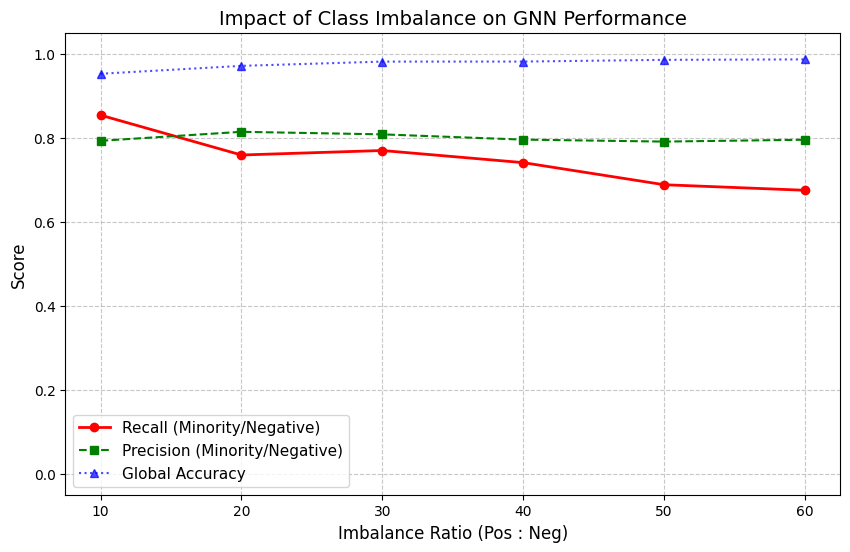


实验结束！结果已保存为 imbalance_experiment_result.png
数据汇总:
   ratio  neg_recall  neg_precision       acc
0     10    0.853746       0.792642  0.952285
1     20    0.758845       0.814098  0.971099
2     30    0.769568       0.807988  0.981232
3     40    0.740689       0.795472  0.981322
4     50    0.688080       0.790812  0.985403
5     60    0.674873       0.795222  0.986497


In [ ]:
import glob
import matplotlib.pyplot as plt
from pathlib import Path

# 设置路径
data_dir = Path("data_signed")
node_csv_path = "data/node.csv" # 你的节点文件路径

# 找到所有生成的数据集 (edges_labeled_pos10x.csv, 20x...)
# 并按倍率排序
files = sorted(data_dir.glob("edges_labeled_pos*x.csv"), 
               key=lambda x: int(x.stem.split('pos')[1][:-1]))

summary_results = []

print(f"找到 {len(files)} 个数据集，开始压力测试...")

for f in files:
    ratio = int(f.stem.split('pos')[1][:-1])
    print(f"\n{'='*30}")
    print(f"正在测试倍率: {ratio}x (文件: {f.name})")
    print(f"{'='*30}")
    
    # === 调用你的训练函数 ===
    # 注意：prepare_data 会自动根据 label 1 的数量生成等量的 label 0
    # 所以这里不仅测试了 Pos 变多，也测试了 No-Edge 变多，完美符合实验设计
    model, metrics = train_model_unbalance(node_csv_path, str(f))
    
    # 记录结果
    summary_results.append({
        "ratio": ratio,
        "neg_recall": metrics["neg_recall"],
        "neg_precision": metrics["neg_precision"],
        "acc": metrics["acc"]
    })

# ==========================
# 第三步：可视化实验结果
# ==========================
ratios = [item['ratio'] for item in summary_results]
recalls = [item['neg_recall'] for item in summary_results]
precs = [item['neg_precision'] for item in summary_results]
accs = [item['acc'] for item in summary_results]

plt.figure(figsize=(10, 6))

# 1. 绘制 Negative Recall (红色 - 应该会下降)
plt.plot(ratios, recalls, 'r-o', linewidth=2, label='Recall (Minority/Negative)')

# 2. 绘制 Negative Precision (绿色)
plt.plot(ratios, precs, 'g--s', linewidth=1.5, label='Precision (Minority/Negative)')

# 3. 绘制 Global Accuracy (蓝色 - 可能会上升或持平，具有欺骗性)
plt.plot(ratios, accs, 'b:^', linewidth=1.5, alpha=0.7, label='Global Accuracy')

plt.title("Impact of Class Imbalance on GNN Performance", fontsize=14)
plt.xlabel("Imbalance Ratio (Pos : Neg)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(ratios)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.ylim(-0.05, 1.05)

# 保存图片
plt.savefig("imbalance_experiment_result.png", dpi=300)
plt.show()

print("\n实验结束！结果已保存为 imbalance_experiment_result.png")
print("数据汇总:")
print(pd.DataFrame(summary_results))

# Uniform test reverse

找到 6 个数据集，开始压力测试...

正在测试倍率: 10x (文件: edges_labeled_ratio10x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 6861
采样后总数据量: 144081 (其中 Label 0: 68610)
training HGTModel in unbanlance test..................


[Ep 19] Val_Loss=213.1977 | Acc=0.7314 | F1=0.7509 | AUC=0.8826 | AP=0.8293 | Neg_Rec=0.7630 | Neg_Pre=0.8617

正在测试倍率: 20x (文件: edges_labeled_ratio20x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 3430
采样后总数据量: 140650 (其中 Label 0: 68610)
training HGTModel in unbanlance test..................


[Ep 19] Val_Loss=220.4347 | Acc=0.7181 | F1=0.7118 | AUC=0.8735 | AP=0.7905 | Neg_Rec=0.6745 | Neg_Pre=0.7558

正在测试倍率: 30x (文件: edges_labeled_ratio30x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 2287
采样后总数据量: 139507 (其中 Label 0: 68610)
training HGTModel in unbanlance test..................


[Ep 19] Val_Loss=209.9014 | Acc=0.7391 | F1=0.6801 | AUC=0.8642 | AP=0.7404 | Neg_Rec=0.4541 | Neg_Pre=0.7409

正在测试倍率: 40x (文件: edges_labeled_ratio40x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 1715
采样后总数据量: 138935 (其中 Label 0: 68610)
training HGTModel in unbanlance test..................


[Ep 19] Val_Loss=221.4853 | Acc=0.7220 | F1=0.6392 | AUC=0.8516 | AP=0.6884 | Neg_Rec=0.4048 | Neg_Pre=0.5953

正在测试倍率: 50x (文件: edges_labeled_ratio50x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 1372
采样后总数据量: 138592 (其中 Label 0: 68610)
training HGTModel in unbanlance test..................


[Ep 19] Val_Loss=206.6298 | Acc=0.7359 | F1=0.6566 | AUC=0.8617 | AP=0.7117 | Neg_Rec=0.3980 | Neg_Pre=0.6836

正在测试倍率: 60x (文件: edges_labeled_ratio60x.csv)
正在准备数据...
原始数据统计: Label 1 (Pos) = 68610, Label 2 (Neg) = 1143
采样后总数据量: 138363 (其中 Label 0: 68610)
training HGTModel in unbanlance test..................


[Ep 19] Val_Loss=222.5721 | Acc=0.7224 | F1=0.6319 | AUC=0.8515 | AP=0.6773 | Neg_Rec=0.3859 | Neg_Pre=0.5636


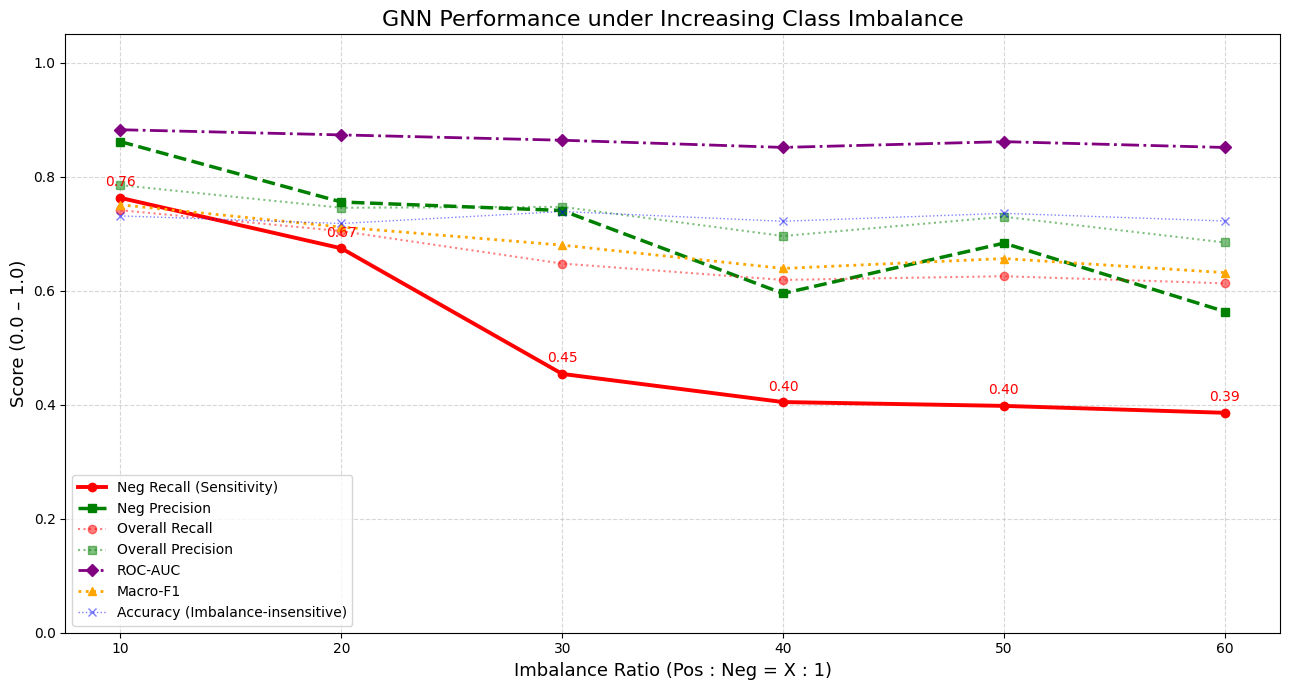

   ratio        loss       acc  macro_f1       auc        ap  neg_recall  \
0     10  213.197734  0.731409  0.750887  0.882598  0.829288    0.762968   
1     20  220.434662  0.718130  0.711839  0.873530  0.790487    0.674521   
2     30  209.901410  0.739087  0.680100  0.864203  0.740431    0.454139   
3     40  221.485303  0.721956  0.639238  0.851583  0.688350    0.404762   
4     50  206.629795  0.735921  0.656558  0.861692  0.711722    0.398026   
5     60  222.572061  0.722437  0.631872  0.851499  0.677307    0.385892   

   neg_precision  overall_rec  overall_pre  
0       0.861676     0.741394     0.785384  
1       0.755776     0.704683     0.745685  
2       0.740876     0.647762     0.747255  
3       0.595331     0.619100     0.696145  
4       0.683616     0.625568     0.729924  
5       0.563636     0.613068     0.684784  


In [3]:
# Uniform test reverse
import glob
import matplotlib.pyplot as plt
from pathlib import Path

# 设置路径
data_dir = Path("data_signed_reversed")
node_csv_path = "/home/yyyy/codework/GARplus/GNN/code/data_signed_reversed/node_labeled.csv"
# 找到所有生成的数据集 (edges_labeled_pos10x.csv, 20x...)
# 并按倍率排序
files = sorted(data_dir.glob("edges_labeled_ratio*x.csv"), 
               key=lambda x: int(x.stem.split('ratio')[1][:-1]))

summary_results = []

print(f"找到 {len(files)} 个数据集，开始压力测试...")

for f in files:
    ratio = int(f.stem.split('ratio')[1][:-1])
    print(f"\n{'='*30}")
    print(f"正在测试倍率: {ratio}x (文件: {f.name})")
    print(f"{'='*30}")
    
    # === 调用你的训练函数 ===
    # 注意：prepare_data 会自动根据 label 1 的数量生成等量的 label 0
    # 所以这里不仅测试了 Pos 变多，也测试了 No-Edge 变多，完美符合实验设计
    model, metrics = train_model_unbalance(node_csv_path, str(f))
    
    # 记录结果：保存所有返回的指标
    summary_results.append({
        "ratio": ratio,
        "loss": metrics["loss"],
        "acc": metrics["acc"],
        "macro_f1": metrics["macro_f1"],
        "auc": metrics["auc"],
        "ap": metrics["ap"],
        "neg_recall": metrics["neg_recall"],
        "neg_precision": metrics["neg_precision"],
        "overall_rec":metrics["rec"],
        "overall_pre": metrics["pre"]
    })
import matplotlib.pyplot as plt

# ==========================
# 第三步：可视化实验结果 (修改版)
# ==========================

# 1. 提取数据列表
ratios = [item['ratio'] for item in summary_results]

# Negative-class metrics (核心)
neg_recalls = [item['neg_recall'] for item in summary_results]
neg_precs   = [item['neg_precision'] for item in summary_results]

# Overall metrics（对照）
overall_recalls = [item['overall_rec'] for item in summary_results]
overall_precs   = [item['overall_pre'] for item in summary_results]

# Global metrics
aucs = [item['auc'] for item in summary_results]
f1s  = [item['macro_f1'] for item in summary_results]
accs = [item['acc'] for item in summary_results]

plt.figure(figsize=(13, 7))

# ==========================
# 核心：Negative class
# ==========================

# Negative Recall（红色粗实线）
plt.plot(
    ratios, neg_recalls,
    color='red', marker='o', linestyle='-', linewidth=2.8,
    label='Neg Recall (Sensitivity)'
)

# Negative Precision（绿色粗虚线）
plt.plot(
    ratios, neg_precs,
    color='green', marker='s', linestyle='--', linewidth=2.5,
    label='Neg Precision'
)

# ==========================
# 对照：Overall metrics
# ==========================

# Overall Recall（红色细点线）
plt.plot(
    ratios, overall_recalls,
    color='red', marker='o', linestyle=':', linewidth=1.5, alpha=0.5,
    label='Overall Recall'
)

# Overall Precision（绿色细点线）
plt.plot(
    ratios, overall_precs,
    color='green', marker='s', linestyle=':', linewidth=1.5, alpha=0.5,
    label='Overall Precision'
)

# ==========================
# 全局排序 / 综合指标
# ==========================

# AUC（紫色点划线）
plt.plot(
    ratios, aucs,
    color='purple', marker='D', linestyle='-.', linewidth=2,
    label='ROC-AUC'
)

# Macro-F1（橙色点线）
plt.plot(
    ratios, f1s,
    color='orange', marker='^', linestyle=':', linewidth=2,
    label='Macro-F1'
)

# Accuracy（蓝色细线，弱化）
plt.plot(
    ratios, accs,
    color='blue', marker='x', linestyle=':', linewidth=1,
    alpha=0.5, label='Accuracy (Imbalance-insensitive)'
)

# ==========================
# 图表装饰
# ==========================

plt.title("GNN Performance under Increasing Class Imbalance", fontsize=16)
plt.xlabel("Imbalance Ratio (Pos : Neg = X : 1)", fontsize=13)
plt.ylabel("Score (0.0 – 1.0)", fontsize=13)

plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='best')

# 只给 Neg Recall 加数值标注（最核心）
for x, y in zip(ratios, neg_recalls):
    plt.text(x, y + 0.015, f"{y:.2f}", ha='center', va='bottom',
             fontsize=10, color='red')

plt.tight_layout()
plt.show()

print(pd.DataFrame(summary_results))

In [2]:
print("正在处理：", "data_signed/edges_labeled_pos10x.csv",)
model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos10x.csv")
print(cur_results)
print("=============================================================================")

正在处理： data_signed/edges_labeled_pos10x.csv


Epoch 00: 100%|████████████████████████████████████| 1801/1801 [00:25<00:00, 69.76it/s, loss=0.4686]


[Epoch 00] Train Loss=1021.5014 | Val Loss=62.1839 | Acc=0.7590 | Pre=0.7943 | Rec=0.5946 | F1=0.6208 | AUC=0.8965 | PRC=0.7425


Epoch 01: 100%|████████████████████████████████████| 1801/1801 [00:22<00:00, 79.23it/s, loss=0.6477]


[Epoch 01] Train Loss=858.8988 | Val Loss=53.6974 | Acc=0.7908 | Pre=0.8143 | Rec=0.6836 | F1=0.7158 | AUC=0.9217 | PRC=0.8140


...

[Epoch 17] Train Loss=670.0804 | Val Loss=46.3756 | Acc=0.8229 | Pre=0.8439 | Rec=0.7819 | F1=0.7975 | AUC=0.9492 | PRC=0.8914


Epoch 18: 100%|████████████████████████████████████| 1801/1801 [00:22<00:00, 78.88it/s, loss=0.3572]


[Epoch 18] Train Loss=671.6444 | Val Loss=47.9952 | Acc=0.8156 | Pre=0.8548 | Rec=0.7700 | F1=0.7922 | AUC=0.9501 | PRC=0.8942


Epoch 19: 100%|████████████████████████████████████| 1801/1801 [00:23<00:00, 77.84it/s, loss=0.3122]


[Epoch 19] Train Loss=666.0418 | Val Loss=46.0791 | Acc=0.8236 | Pre=0.8405 | Rec=0.7955 | F1=0.8037 | AUC=0.9508 | PRC=0.8970
训练完成！
{'train_loss': [1021.5014381110668, 858.8988242894411, 804.2088388204575, 774.6864759325981, 757.8417594730854, 741.6388884335756, 730.7565873116255, 721.4253815859556, 714.9646542966366, 708.8106171488762, 704.363007709384, 695.9327276796103, 692.081952854991, 687.7878561764956, 684.7167649567127, 678.8916950076818, 676.0019027590752, 670.0804459899664, 671.6444116979837, 666.0418426990509], 'val_loss': [62.18393591046333, 53.697358429431915, 49.1797793507576, 50.38590911030769, 52.775708854198456, 53.79995974898338, 50.39151802659035, 51.75986164808273, 46.849339097738266, 47.70029437541962, 50.300162732601166, 48.8130721449852, 48.0139938890934, 47.58518731594086, 57.11831894516945, 46.78372973203659, 47.70887181162834, 46.37561121582985, 47.9951890707016, 46.07914978265762], 'prc': [0.7424656872669858, 0.813971868891958, 0.8373732363113399, 0.84772543

In [3]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos20x.csv",)
    model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos20x.csv")
    print(cur_results)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos20x.csv


Epoch 00: 100%|████████████████████████████████████| 3517/3517 [00:49<00:00, 70.68it/s, loss=0.3726]


[Epoch 00] Train Loss=1877.5883 | Val Loss=119.5418 | Acc=0.7453 | Pre=0.6253 | Rec=0.5104 | F1=0.4990 | AUC=0.8841 | PRC=0.6783


Epoch 01: 100%|████████████████████████████████████| 3517/3517 [00:49<00:00, 70.85it/s, loss=0.2723]


[Epoch 01] Train Loss=1619.2104 | Val Loss=126.1839 | Acc=0.7376 | Pre=0.7688 | Rec=0.5855 | F1=0.6114 | AUC=0.9077 | PRC=0.7530


...

[Epoch 17] Train Loss=1342.8954 | Val Loss=109.6165 | Acc=0.7721 | Pre=0.8232 | Rec=0.6999 | F1=0.7268 | AUC=0.9381 | PRC=0.8494


Epoch 18: 100%|████████████████████████████████████| 3517/3517 [00:45<00:00, 77.97it/s, loss=0.4715]


[Epoch 18] Train Loss=1334.7491 | Val Loss=109.8436 | Acc=0.7704 | Pre=0.8170 | Rec=0.7118 | F1=0.7326 | AUC=0.9397 | PRC=0.8564


Epoch 19: 100%|████████████████████████████████████| 3517/3517 [00:44<00:00, 79.92it/s, loss=0.2431]


[Epoch 19] Train Loss=1333.9159 | Val Loss=109.4884 | Acc=0.7728 | Pre=0.7949 | Rec=0.7309 | F1=0.7363 | AUC=0.9378 | PRC=0.8554
训练完成！
{'train_loss': [1877.5883109271526, 1619.2103533744812, 1528.7529337704182, 1480.0625160038471, 1456.0538122206926, 1435.445430919528, 1416.6020234972239, 1405.7856281399727, 1397.424265757203, 1387.904980942607, 1375.4977252036333, 1371.3904068171978, 1366.608160957694, 1360.1760424375534, 1358.1685782819986, 1354.1241614669561, 1343.6876981407404, 1342.8953987509012, 1334.749112740159, 1333.9158664941788], 'val_loss': [119.54184141755104, 126.18391713500023, 121.88036885857582, 117.17189458012581, 113.22032535076141, 118.89975318312645, 116.88930088281631, 113.53129038214684, 109.8750672340393, 115.82789480686188, 115.91524711251259, 115.94403970241547, 114.8860473036766, 113.39837908744812, 106.960667937994, 119.43627440929413, 118.98555785417557, 109.61650168895721, 109.84359532594681, 109.48837473988533], 'prc': [0.6783000503377755, 0.7529773215699

In [4]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos30x.csv",)
    model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos30x.csv")
    print(cur_results)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos30x.csv


Epoch 00: 100%|████████████████████████████████████| 5232/5232 [01:06<00:00, 78.83it/s, loss=0.6276]


[Epoch 00] Train Loss=2627.3342 | Val Loss=200.5806 | Acc=0.7142 | Pre=0.7023 | Rec=0.5562 | F1=0.5703 | AUC=0.8771 | PRC=0.6772


Epoch 01: 100%|████████████████████████████████████| 5232/5232 [01:06<00:00, 78.61it/s, loss=0.4281]


[Epoch 01] Train Loss=2305.8199 | Val Loss=206.1996 | Acc=0.7040 | Pre=0.7573 | Rec=0.5250 | F1=0.5381 | AUC=0.9005 | PRC=0.7255


...

[Epoch 17] Train Loss=1946.4851 | Val Loss=167.0090 | Acc=0.7573 | Pre=0.8275 | Rec=0.6355 | F1=0.6731 | AUC=0.9358 | PRC=0.8267


Epoch 18: 100%|████████████████████████████████████| 5232/5232 [01:09<00:00, 74.75it/s, loss=0.4389]


[Epoch 18] Train Loss=1945.7606 | Val Loss=149.9752 | Acc=0.7847 | Pre=0.8217 | Rec=0.6829 | F1=0.7173 | AUC=0.9388 | PRC=0.8374


Epoch 19: 100%|████████████████████████████████████| 5232/5232 [01:09<00:00, 75.30it/s, loss=0.3067]


[Epoch 19] Train Loss=1938.2490 | Val Loss=159.7053 | Acc=0.7678 | Pre=0.8011 | Rec=0.6930 | F1=0.7146 | AUC=0.9388 | PRC=0.8381
训练完成！
{'train_loss': [2627.3342146277428, 2305.8199160397053, 2202.609375998378, 2149.5929835885763, 2100.3714100569487, 2077.6548322439194, 2050.0164069980383, 2037.522560968995, 2018.686899870634, 2004.0976364910603, 1996.6881675124168, 1987.3615533709526, 1979.6349637806416, 1975.325053036213, 1961.767385929823, 1960.8038970828056, 1953.7665109038353, 1946.4851365089417, 1945.7605514526367, 1938.2490447461605], 'val_loss': [200.58062574267387, 206.19964519143105, 180.391145080328, 179.45515742897987, 191.85271760821342, 176.38972386717796, 174.41072168946266, 163.53587609529495, 158.89223465323448, 154.31088057160378, 158.43466904759407, 167.4288547039032, 163.9345092177391, 159.70057666301727, 158.9560373723507, 166.44297093153, 153.9991464316845, 167.00903153419495, 149.97521367669106, 159.70533934235573], 'prc': [0.6771852694355895, 0.7254643491545757, 

In [5]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos40x.csv",)
    model,dict_imb40 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos40x.csv")
    print(dict_imb40)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos40x.csv


Epoch 00: 100%|████████████████████████████████████| 6947/6947 [01:32<00:00, 75.24it/s, loss=0.5050]


[Epoch 00] Train Loss=3355.6639 | Val Loss=242.1718 | Acc=0.7304 | Pre=0.7929 | Rec=0.5265 | F1=0.5402 | AUC=0.8669 | PRC=0.6416


Epoch 01: 100%|████████████████████████████████████| 6947/6947 [01:33<00:00, 74.55it/s, loss=0.4309]


[Epoch 01] Train Loss=2967.2148 | Val Loss=247.1888 | Acc=0.7342 | Pre=0.7646 | Rec=0.5298 | F1=0.5432 | AUC=0.8889 | PRC=0.6626


...

[Epoch 17] Train Loss=2542.8842 | Val Loss=195.6882 | Acc=0.7881 | Pre=0.7602 | Rec=0.6922 | F1=0.7056 | AUC=0.9357 | PRC=0.8019


Epoch 18: 100%|████████████████████████████████████| 6947/6947 [01:27<00:00, 79.47it/s, loss=0.4890]


[Epoch 18] Train Loss=2529.3833 | Val Loss=218.9075 | Acc=0.7613 | Pre=0.7874 | Rec=0.6449 | F1=0.6739 | AUC=0.9340 | PRC=0.7944


Epoch 19: 100%|████████████████████████████████████| 6947/6947 [01:27<00:00, 79.60it/s, loss=0.4197]


[Epoch 19] Train Loss=2528.0625 | Val Loss=201.0152 | Acc=0.7830 | Pre=0.7721 | Rec=0.6630 | F1=0.6881 | AUC=0.9373 | PRC=0.8013
训练完成！
{'train_loss': [3355.6639197915792, 2967.2147768884897, 2857.0367852449417, 2784.725618958473, 2735.1942146122456, 2698.628760486841, 2670.108947530389, 2646.1108799278736, 2621.066817998886, 2614.8022379130125, 2601.0162702053785, 2588.4906685501337, 2580.958761483431, 2567.2822101563215, 2561.8920793011785, 2554.2887481302023, 2535.2424698770046, 2542.8842367976904, 2529.3833072185516, 2528.0624675750732], 'val_loss': [242.17179384827614, 247.18876135349274, 260.0557629466057, 243.31389689445496, 227.37123614549637, 253.08111786842346, 242.70716553926468, 211.89939600229263, 244.21291944384575, 244.94558477401733, 229.46497076749802, 210.1440567970276, 216.40422981977463, 198.3305861055851, 195.87778070569038, 210.2207261621952, 192.8082913160324, 195.68822339177132, 218.90745005011559, 201.0152454674244], 'prc': [0.6415706906082631, 0.662647557476858

In [6]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos50x.csv",)
    model,dict_imb50 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos50x.csv")
    print(dict_imb50)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos50x.csv


Epoch 00: 100%|████████████████████████████████████| 8662/8662 [01:53<00:00, 76.16it/s, loss=0.4797]


[Epoch 00] Train Loss=4082.5252 | Val Loss=281.3862 | Acc=0.7509 | Pre=0.8689 | Rec=0.5062 | F1=0.4990 | AUC=0.8732 | PRC=0.6582


Epoch 01: 100%|████████████████████████████████████| 8662/8662 [01:53<00:00, 76.16it/s, loss=0.3698]


[Epoch 01] Train Loss=3504.0165 | Val Loss=254.6846 | Acc=0.7798 | Pre=0.7859 | Rec=0.5925 | F1=0.6258 | AUC=0.9018 | PRC=0.7074


...

[Epoch 17] Train Loss=3081.1124 | Val Loss=241.0336 | Acc=0.7942 | Pre=0.8094 | Rec=0.6614 | F1=0.6982 | AUC=0.9370 | PRC=0.7954


Epoch 18: 100%|████████████████████████████████████| 8662/8662 [01:53<00:00, 76.59it/s, loss=0.3095]


[Epoch 18] Train Loss=3072.1780 | Val Loss=231.9538 | Acc=0.8017 | Pre=0.8266 | Rec=0.6446 | F1=0.6867 | AUC=0.9338 | PRC=0.7939


Epoch 19: 100%|████████████████████████████████████| 8662/8662 [01:53<00:00, 76.30it/s, loss=0.2436]


[Epoch 19] Train Loss=3072.8827 | Val Loss=236.0076 | Acc=0.7969 | Pre=0.8088 | Rec=0.6650 | F1=0.7017 | AUC=0.9357 | PRC=0.7977
训练完成！
{'train_loss': [4082.5251926481724, 3504.016455978155, 3372.1061646044254, 3303.0209147185087, 3257.9658253639936, 3222.351941637695, 3197.660916931927, 3181.9994995296, 3165.263869330287, 3153.463586449623, 3138.3266718685627, 3128.980640158057, 3116.4146521687508, 3102.3123228102922, 3095.579990670085, 3093.5487107634544, 3087.373052597046, 3081.1124176084995, 3072.1779734641314, 3072.8827477246523], 'val_loss': [281.3862214386463, 254.68463802337646, 272.010790258646, 251.19591853022575, 248.59842923283577, 245.05153185129166, 252.05664825439453, 260.1130701005459, 245.60779055953026, 257.74589306116104, 250.81863823533058, 250.42548578977585, 233.66066631674767, 235.72500002384186, 232.76842692494392, 243.04188591241837, 229.79121258854866, 241.0335749089718, 231.95384669303894, 236.00761878490448], 'prc': [0.6582442397548097, 0.7074228784613349, 0.

In [11]:

if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos60x.csv",)
    model,dict_imb60 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos60x.csv")
    print(dict_imb60)
    print("=============================================================================")

正在处理： data_signed/edges_labeled_pos60x.csv


Epoch 00: 100%|██████████████████████████████████| 10378/10378 [02:23<00:00, 72.10it/s, loss=0.2964]


[Epoch 00] Train Loss=4661.0009 | Val Loss=319.9077 | Acc=0.7669 | Pre=0.5378 | Rec=0.5152 | F1=0.5087 | AUC=0.8595 | PRC=0.6172


Epoch 01: 100%|██████████████████████████████████| 10378/10378 [02:23<00:00, 72.46it/s, loss=0.3559]


[Epoch 01] Train Loss=4121.1022 | Val Loss=330.2598 | Acc=0.7536 | Pre=0.5407 | Rec=0.5062 | F1=0.4972 | AUC=0.8976 | PRC=0.6405


...

[Epoch 17] Train Loss=3594.9425 | Val Loss=255.9492 | Acc=0.8205 | Pre=0.8320 | Rec=0.5786 | F1=0.5978 | AUC=0.9334 | PRC=0.7358


Epoch 18: 100%|██████████████████████████████████| 10378/10378 [02:24<00:00, 71.99it/s, loss=0.2215]


[Epoch 18] Train Loss=3587.2707 | Val Loss=257.2841 | Acc=0.8178 | Pre=0.8106 | Rec=0.6369 | F1=0.6756 | AUC=0.9384 | PRC=0.7752


Epoch 19: 100%|██████████████████████████████████| 10378/10378 [02:23<00:00, 72.18it/s, loss=0.4571]


[Epoch 19] Train Loss=3579.0262 | Val Loss=248.7836 | Acc=0.8277 | Pre=0.8301 | Rec=0.6118 | F1=0.6456 | AUC=0.9381 | PRC=0.7604
训练完成！
{'train_loss': [4661.000874042511, 4121.102180808783, 3971.0364537090063, 3885.988481923938, 3822.7264528125525, 3784.2074640244246, 3740.047464236617, 3708.658115670085, 3689.0344011187553, 3676.3574073165655, 3659.047667220235, 3643.772821098566, 3637.362204000354, 3628.3457558602095, 3617.098372682929, 3606.134112790227, 3598.646329678595, 3594.9425439983606, 3587.2707431465387, 3579.0261850729585], 'val_loss': [319.9076750576496, 330.2598112523556, 319.74279552698135, 310.9854253232479, 317.6853936612606, 307.59848111867905, 274.1135968565941, 262.3671116232872, 268.5834243297577, 274.2485408782959, 274.6723628938198, 273.86663272976875, 259.6252816617489, 252.8621783554554, 269.6751181483269, 266.6423372924328, 249.26907724142075, 255.94924691319466, 257.28414312005043, 248.7836087346077], 'prc': [0.6172449662165743, 0.6404869024244271, 0.665843977

In [12]:
dict_imb10 = {'train_loss': [1021.5014381110668, 858.8988242894411, 804.2088388204575, 774.6864759325981, 757.8417594730854, 741.6388884335756, 730.7565873116255, 721.4253815859556, 714.9646542966366, 708.8106171488762, 704.363007709384, 695.9327276796103, 692.081952854991, 687.7878561764956, 684.7167649567127, 678.8916950076818, 676.0019027590752, 670.0804459899664, 671.6444116979837, 666.0418426990509], 'val_loss': [62.18393591046333, 53.697358429431915, 49.1797793507576, 50.38590911030769, 52.775708854198456, 53.79995974898338, 50.39151802659035, 51.75986164808273, 46.849339097738266, 47.70029437541962, 50.300162732601166, 48.8130721449852, 48.0139938890934, 47.58518731594086, 57.11831894516945, 46.78372973203659, 47.70887181162834, 46.37561121582985, 47.9951890707016, 46.07914978265762], 'prc': [0.7424656872669858, 0.813971868891958, 0.8373732363113399, 0.8477254308289345, 0.8548771923385412, 0.860467735472366, 0.8695275840201618, 0.8666956476859907, 0.8813963939131099, 0.8780231860610274, 0.8861399808571124, 0.8831070058386158, 0.8821016158048698, 0.8881515895798016, 0.886500548609482, 0.8910897798440619, 0.889923155586407, 0.8914224416050877, 0.8942423440236545, 0.8969604894806396], 'auc': [0.8965446720565958, 0.9216846597674514, 0.9288172056389535, 0.9318575050337108, 0.9345772059394671, 0.9365784620651937, 0.9389282687643993, 0.9409923627072688, 0.9448425342567427, 0.9428939721931989, 0.9454087045829312, 0.9450661361854359, 0.9459221780366196, 0.9449498846340857, 0.9437197793425952, 0.9481267879493309, 0.9475870755853699, 0.9492077306669676, 0.9501145835363903, 0.9507948102218854], 'f1': [0.6208430183179207, 0.7157615353047401, 0.7534168381291516, 0.756434664213847, 0.7457612818515439, 0.7381340362141859, 0.776475847778471, 0.7316058299067127, 0.7824253432972771, 0.7891507786841426, 0.7824607500363941, 0.7866654146577993, 0.7773249004668948, 0.7944819230146442, 0.7675880585198627, 0.7988240347070653, 0.7874052759298067, 0.7974827804461904, 0.7922060623526276, 0.8036873686710609]}
dict_imb20 = {'train_loss': [1877.5883109271526, 1619.2103533744812, 1528.7529337704182, 1480.0625160038471, 1456.0538122206926, 1435.445430919528, 1416.6020234972239, 1405.7856281399727, 1397.424265757203, 1387.904980942607, 1375.4977252036333, 1371.3904068171978, 1366.608160957694, 1360.1760424375534, 1358.1685782819986, 1354.1241614669561, 1343.6876981407404, 1342.8953987509012, 1334.749112740159, 1333.9158664941788], 'val_loss': [119.54184141755104, 126.18391713500023, 121.88036885857582, 117.17189458012581, 113.22032535076141, 118.89975318312645, 116.88930088281631, 113.53129038214684, 109.8750672340393, 115.82789480686188, 115.91524711251259, 115.94403970241547, 114.8860473036766, 113.39837908744812, 106.960667937994, 119.43627440929413, 118.98555785417557, 109.61650168895721, 109.84359532594681, 109.48837473988533], 'prc': [0.6783000503377755, 0.7529773215699076, 0.7933465759689732, 0.8111796597349469, 0.8220813434034864, 0.8281626113223416, 0.8287842016223768, 0.8341497785659716, 0.8362559604016083, 0.834767761078346, 0.832154731748823, 0.8488843851981658, 0.8462295249368061, 0.8521388840428537, 0.8457023694123675, 0.853980334868409, 0.853837909691762, 0.8493511621882867, 0.8563897781773782, 0.8553630990587883], 'auc': [0.8841418542766917, 0.9077288252376232, 0.9147477279965189, 0.9232541391026582, 0.9255039991077606, 0.9251706953781955, 0.9275112951554334, 0.929819568238537, 0.9303727231578202, 0.9311023284316341, 0.9303264074818333, 0.9341178007243234, 0.9351309872554844, 0.9348133414527512, 0.937289150866547, 0.9373443507519937, 0.9374822199576323, 0.9380846540821542, 0.9396993297350146, 0.9378273992590982], 'f1': [0.4989856917364443, 0.6114388818835692, 0.6765006878312221, 0.6929784477989367, 0.7091377259770827, 0.7064931890701871, 0.7082863802333064, 0.7129102138168868, 0.7053009573575114, 0.7170481433544885, 0.7104242556090727, 0.6990336628212391, 0.7036899101608695, 0.731901848422453, 0.7081293569353169, 0.7189731527412521, 0.7164460957338425, 0.7268368618243755, 0.7326479365753422, 0.7362618090023266]}
dict_imb30 = {'train_loss': [2627.3342146277428, 2305.8199160397053, 2202.609375998378, 2149.5929835885763, 2100.3714100569487, 2077.6548322439194, 2050.0164069980383, 2037.522560968995, 2018.686899870634, 2004.0976364910603, 1996.6881675124168, 1987.3615533709526, 1979.6349637806416, 1975.325053036213, 1961.767385929823, 1960.8038970828056, 1953.7665109038353, 1946.4851365089417, 1945.7605514526367, 1938.2490447461605], 'val_loss': [200.58062574267387, 206.19964519143105, 180.391145080328, 179.45515742897987, 191.85271760821342, 176.38972386717796, 174.41072168946266, 163.53587609529495, 158.89223465323448, 154.31088057160378, 158.43466904759407, 167.4288547039032, 163.9345092177391, 159.70057666301727, 158.9560373723507, 166.44297093153, 153.9991464316845, 167.00903153419495, 149.97521367669106, 159.70533934235573], 'prc': [0.6771852694355895, 0.7254643491545757, 0.7696388575508938, 0.7858157210148646, 0.7858232219968028, 0.8000151290792825, 0.805880448797731, 0.8138901079406972, 0.813937669554484, 0.8200220444087746, 0.8225835030353549, 0.8289898129495535, 0.8171985253236631, 0.8323575807452039, 0.8360569751928567, 0.8381946936235698, 0.8371336363019125, 0.8267020250139122, 0.8373912915032745, 0.838080046070632], 'auc': [0.8771460131798309, 0.900468474980679, 0.9110667955802335, 0.9156314244788629, 0.9201487099032827, 0.9253775301160729, 0.9261514833959303, 0.927791835799015, 0.9304360647000234, 0.9332742766905956, 0.933087758701815, 0.9347847537737869, 0.9320286203536327, 0.9377430420763688, 0.9379900386683052, 0.9381483128719624, 0.9383069664152776, 0.9358353247935977, 0.9387628398946748, 0.938826221824867], 'f1': [0.5702856060349577, 0.5381462756252086, 0.6274916389861257, 0.6592321398423152, 0.5981153567776372, 0.661856063048419, 0.6692769235381933, 0.692130618864596, 0.6938103491742256, 0.6942463253276198, 0.699333449657903, 0.7042539296915479, 0.6583557531504771, 0.7010244086488419, 0.7195549580120072, 0.7067964456399198, 0.7191720042674378, 0.6730729397159957, 0.717264022677766, 0.7146310561302004]}
# dict_imb40 = {'train_loss': [2888.7224815040827, 2643.346618205309, 2580.6205416321754, 2523.9436548650265, 2487.181392982602, 2459.600594982505, 2439.154680877924, 2424.824578307569, 2412.7243489176035, 2396.0795468240976, 2376.452445194125, 2361.535987585783, 2343.4935272559524, 2325.949218943715, 2311.050811931491, 2299.677842028439, 2286.880014292896, 2279.319395072758, 2270.5585660859942, 2262.9323414713144], 'val_loss': [172.30013591051102, 167.03588935732841, 162.9113792181015, 160.33617220818996, 159.4134799093008, 156.6752391308546, 157.10942436754704, 157.59894394874573, 155.78771771490574, 153.80309891700745, 153.05701476335526, 151.624218583107, 152.8735183030367, 151.09714183211327, 150.10812810063362, 148.49789489805698, 149.42810885608196, 148.51331989467144, 147.31063605844975, 147.95475874841213], 'prc': [0.695872354941894, 0.7292384096693071, 0.7384701368962766, 0.742165677716263, 0.7485824430692379, 0.7552904050332522, 0.7598434069147282, 0.7582143448021855, 0.7560283092116767, 0.7667171047450679, 0.7668741565256255, 0.770916779730017, 0.7735423454090768, 0.7674917460557144, 0.7796141287017928, 0.7858974451041875, 0.7824243113848143, 0.785611275964126, 0.7922169432896005, 0.7854731558948127], 'auc': [0.8938601762964907, 0.9069943461976728, 0.9108190352131609, 0.9141719933637953, 0.9165375220582482, 0.9189541297733315, 0.9208344657449509, 0.9199407532297541, 0.9213313692774198, 0.9248748436957869, 0.9262359669093824, 0.9275212746352057, 0.9290590021666781, 0.9281539126837796, 0.9311553113221892, 0.9322900837266926, 0.9313307691115554, 0.9336621465375067, 0.9353889954055276, 0.9333229211754653], 'f1': [0.6174914854003133, 0.6456583878908558, 0.6837782782164101, 0.7086803411982202, 0.7028171559791091, 0.7082444978079879, 0.7005404082879295, 0.6653794840373689, 0.7197876514737865, 0.6811757387613536, 0.7079225448007115, 0.7155686649785699, 0.7150742788602599, 0.727088030785073, 0.7284161741911772, 0.7171991370204237, 0.7349926883815302, 0.7324791317359759, 0.7222979903164731, 0.7353277289309602]}
# dict_imb50 = {'train_loss': [3537.8309169709682, 3274.8481382727623, 3180.7026700675488, 3121.6912850141525, 3082.1837308108807, 3053.935326576233, 3024.4820843189955, 3004.2504533976316, 2983.3000273406506, 2962.6015799045563, 2947.7789652720094, 2936.521381378174, 2924.838644295931, 2915.7991662546992, 2900.6207714676857, 2888.6125395447016, 2877.6897223219275, 2866.802934244275, 2858.4719399511814, 2849.572202153504], 'val_loss': [207.93963956832886, 199.52092257142067, 197.10343557596207, 195.1103353202343, 191.36523699760437, 188.61311456561089, 189.6190893650055, 185.80015882849693, 186.07043731212616, 186.0740061402321, 185.16281682252884, 185.84542542696, 182.84402422606945, 183.4512225985527, 183.50845181941986, 183.70767050981522, 181.06382317841053, 181.62525172531605, 182.77028684318066, 181.31068965792656], 'prc': [0.6954710524923801, 0.7309581141529025, 0.7348455852383062, 0.7491151034319653, 0.7515547465766144, 0.7654458276662749, 0.7614272040953832, 0.7687520191226044, 0.7699596670019148, 0.7671631663410449, 0.7723471012512064, 0.7745487058519669, 0.7751913433350707, 0.7780274795996153, 0.7764072681886703, 0.7758428420678634, 0.7779442631974156, 0.77996853060395, 0.7798029082631787, 0.7832660475273973], 'auc': [0.8983858352802508, 0.9078460502051776, 0.9115347003881068, 0.9127344383013914, 0.9181878529448726, 0.9205327306507858, 0.9206015389709957, 0.9243340424267493, 0.9247883339977824, 0.925355366356114, 0.9263719205134274, 0.927696434754088, 0.9285986859731934, 0.9293154598827599, 0.9298218098885457, 0.9291956353494775, 0.9311605749423423, 0.9314326025450477, 0.9309683454580763, 0.9332233630841099], 'f1': [0.6221251877514582, 0.6389072961937191, 0.7051914490590897, 0.6401603881936947, 0.7111857901390026, 0.6728548465524654, 0.6665738401187051, 0.7198801860510217, 0.7231326431342078, 0.7284912036950889, 0.6951979736479134, 0.7256272047900097, 0.7280635527686555, 0.7247538122154388, 0.7314396952390858, 0.7342406785511191, 0.7334088920403984, 0.6904320300381565, 0.7330147629593696, 0.7302461536953282]}
# dict_imb60 ={'train_loss': [4183.67197740078, 3883.1144286692142, 3811.2266265153885, 3754.560053884983, 3710.3762929439545, 3669.1832610815763, 3639.9832013994455, 3605.637096181512, 3579.221229739487, 3557.7652866095304, 3537.0565503910184, 3519.8286170959473, 3506.1457823067904, 3490.8157343268394, 3476.9158235639334, 3463.686419710517, 3454.270641490817, 3441.128832742572, 3429.3257678076625, 3420.5781932622194], 'val_loss': [250.22983992099762, 239.84954172372818, 236.89440056681633, 234.33000427484512, 233.9876367598772, 231.11823642253876, 229.3301856070757, 227.41550958156586, 230.035381346941, 226.87125000357628, 222.98087012767792, 222.58405700325966, 223.20345851778984, 223.7851179242134, 219.2671072334051, 217.06723895668983, 218.41490553319454, 218.35604225099087, 220.95187897980213, 218.52301354706287], 'prc': [0.7041608357678958, 0.7356972257372568, 0.7392838279666697, 0.7455292665005389, 0.7455342010835752, 0.7607282901791184, 0.7653688121554098, 0.7664494008977067, 0.7665959063463751, 0.771537451132209, 0.7739476650356053, 0.7832522707756696, 0.7774556241939338, 0.778835895052869, 0.7854255092819414, 0.7894363453649458, 0.7857406327740701, 0.7844608057394383, 0.7539196092961186, 0.7849145734380601], 'auc': [0.9005220011448253, 0.9117633593533282, 0.9170794482775252, 0.920340531783927, 0.9206364131239503, 0.9266308027027123, 0.9270898499746753, 0.9294079934946989, 0.9289561618769765, 0.9311813110648565, 0.932371470782869, 0.9332701098075776, 0.9333798401717021, 0.9345939343578366, 0.9353718922577924, 0.9379141857980217, 0.9356019104116617, 0.9367187496917534, 0.9343841131783378, 0.9369748771734897], 'f1': [0.561174107609752, 0.6318979384133548, 0.6786248550029074, 0.6305316759748051, 0.5907652866128191, 0.6963638227777204, 0.6697250321798346, 0.6340544715568187, 0.6546267538709448, 0.7246219015102988, 0.6821424955502615, 0.6836756534722617, 0.7326193990848434, 0.7381826656153931, 0.6975039540999334, 0.7133178940198409, 0.6946739012319738, 0.7248656508039272, 0.6996531948857774, 0.6824388249051893]}

In [13]:
print(dict_imb60)

{'train_loss': [4661.000874042511, 4121.102180808783, 3971.0364537090063, 3885.988481923938, 3822.7264528125525, 3784.2074640244246, 3740.047464236617, 3708.658115670085, 3689.0344011187553, 3676.3574073165655, 3659.047667220235, 3643.772821098566, 3637.362204000354, 3628.3457558602095, 3617.098372682929, 3606.134112790227, 3598.646329678595, 3594.9425439983606, 3587.2707431465387, 3579.0261850729585], 'val_loss': [319.9076750576496, 330.2598112523556, 319.74279552698135, 310.9854253232479, 317.6853936612606, 307.59848111867905, 274.1135968565941, 262.3671116232872, 268.5834243297577, 274.2485408782959, 274.6723628938198, 273.86663272976875, 259.6252816617489, 252.8621783554554, 269.6751181483269, 266.6423372924328, 249.26907724142075, 255.94924691319466, 257.28414312005043, 248.7836087346077], 'prc': [0.6172449662165743, 0.6404869024244271, 0.6658439776646595, 0.6707129394208377, 0.7037161117037344, 0.7170261601022968, 0.7478686544398916, 0.7478922069336891, 0.7120057449268465, 0.7529

=== Final metrics (last epoch) and drop% vs baseline ===
imbalance	auc_final	prc_final	f1_final	auc_drop%	prc_drop%	f1_drop%
10	0.950795	0.896960	0.803687	0.00	0.00	0.00
20	0.937827	0.855363	0.736262	1.36	4.64	8.39
30	0.938826	0.838080	0.714631	1.26	6.56	11.08
40	0.933323	0.785473	0.735328	1.84	12.43	8.51
50	0.933223	0.783266	0.730246	1.85	12.68	9.14
60	0.938133	0.760430	0.645586	1.33	15.22	19.67


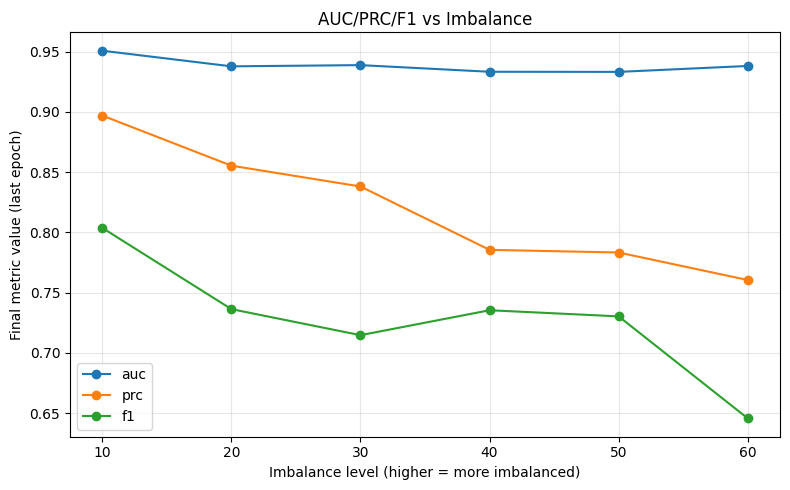

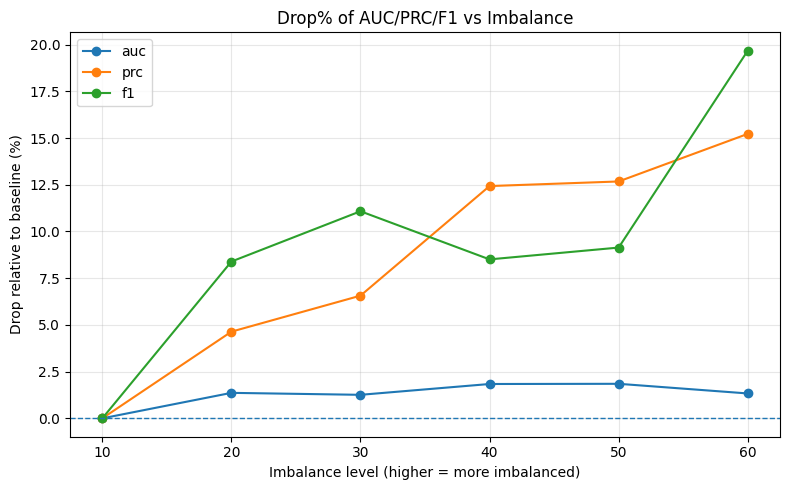

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def summarize_last_metrics(all_results, metrics=None):
    """
    all_results: list of dict, each dict like:
        {
          'train_loss': [...], 'val_loss': [...], 'auc': [...], 'prc': [...], 'f1': [...]
        }
    metrics: list of metric names you want to track. If None, auto-detect common ones.
    return:
        last_vals: dict(metric -> np.array shape [n_runs])
    """
    if metrics is None:
        # 自动从第一组里找指标 key
        metrics = list(all_results[0].keys())

    n = len(all_results)
    last_vals = {m: np.zeros(n, dtype=float) for m in metrics}

    for i, res in enumerate(all_results):
        for m in metrics:
            if m not in res:
                raise KeyError(f"Metric '{m}' not found in run {i}.")
            if len(res[m]) == 0:
                raise ValueError(f"Metric '{m}' list is empty in run {i}.")
            last_vals[m][i] = float(res[m][-1])  # 取最后一个

    return last_vals

def percent_drop(last_vals, baseline_idx=0):
    """
    last_vals: dict(metric -> np.array)
    baseline_idx: which run to treat as baseline (most balanced)
    return:
        drops: dict(metric -> np.array)  # drop% relative to baseline
    """
    drops = {}
    for m, arr in last_vals.items():
        base = arr[baseline_idx]
        # 防止 base=0
        if np.isclose(base, 0):
            drops[m] = np.full_like(arr, np.nan)
        else:
            drops[m] = (base - arr) / base * 100.0
    return drops

def plot_metrics_vs_imbalance(imbalance_levels, last_vals, metrics_to_plot=None, 
                             title="Metrics vs Imbalance"):
    """
    imbalance_levels: list/np.array length n_runs, x-axis
    last_vals: dict(metric -> np.array)
    metrics_to_plot: choose subset to plot; None means plot all
    """
    x = np.array(imbalance_levels, dtype=float)
    if metrics_to_plot is None:
        metrics_to_plot = list(last_vals.keys())

    plt.figure(figsize=(8,5))
    for m in metrics_to_plot:
        y = last_vals[m]
        plt.plot(x, y, marker='o', label=m)

    plt.xlabel("Imbalance level (higher = more imbalanced)")
    plt.ylabel("Final metric value (last epoch)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_drop_vs_imbalance(imbalance_levels, drops, metrics_to_plot=None,
                           title="Percent drop vs Imbalance"):
    x = np.array(imbalance_levels, dtype=float)
    if metrics_to_plot is None:
        metrics_to_plot = list(drops.keys())

    plt.figure(figsize=(8,5))
    for m in metrics_to_plot:
        y = drops[m]
        plt.plot(x, y, marker='o', label=m)

    plt.xlabel("Imbalance level (higher = more imbalanced)")
    plt.ylabel("Drop relative to baseline (%)")
    plt.title(title)
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def print_summary_table(imbalance_levels, last_vals, drops, metrics=None):
    if metrics is None:
        metrics = list(last_vals.keys())

    print("=== Final metrics (last epoch) and drop% vs baseline ===")
    header = ["imbalance"] + [f"{m}_final" for m in metrics] + [f"{m}_drop%" for m in metrics]
    print("\t".join(header))

    for i, lvl in enumerate(imbalance_levels):
        row = [str(lvl)]
        row += [f"{last_vals[m][i]:.6f}" for m in metrics]
        row += [("nan" if np.isnan(drops[m][i]) else f"{drops[m][i]:.2f}") for m in metrics]
        print("\t".join(row))


# ==========================
# 你需要改的只有这里
# ==========================

# imbalance_levels: 每组结果对应的不平衡程度（你自己定义）
# 例子：正负样本比 1:1, 1:5, 1:10, 1:20 ...
imbalance_levels = [10, 20, 30, 40,50,60]  # <-- 改成你的

# all_results: 多组训练结果，每组一个 dict
# 下面只放了一个示例，你要把你的多组 dict 都塞进 list
all_results = [
    dict_imb10,
dict_imb20,
dict_imb30,
dict_imb40,
dict_imb50,
dict_imb60
]

# 你想画哪些指标（默认是 all_results[0] 里出现的全部 key）
metrics = ['auc', 'prc', 'f1']  # <-- 想加 val_loss/train_loss 也可以放进来

# ==========================
# 跑起来
# ==========================

last_vals = summarize_last_metrics(all_results, metrics=metrics)
drops = percent_drop(last_vals, baseline_idx=0)

print_summary_table(imbalance_levels, last_vals, drops, metrics=metrics)

plot_metrics_vs_imbalance(
    imbalance_levels, last_vals, metrics_to_plot=metrics,
    title="AUC/PRC/F1 vs Imbalance"
)

plot_drop_vs_imbalance(
    imbalance_levels, drops, metrics_to_plot=metrics,
    title="Drop% of AUC/PRC/F1 vs Imbalance"
)
